INDUSTRY 4.0 - Statistical INFERENCE

In [ ]:
%pip install numpy==1.24.4

In [ ]:
%pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 2.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import files

# Step 1: Upload the Excel file
uploaded = files.upload()

# Step 2: Get the file name
file_name = list(uploaded.keys())[0]

# Step 3: Read the data from the Excel file
# Assuming the relevant data is in the first sheet and you want to read all columns and rows
# If you need to read a specific range or sheet, please provide details.
try:
    data = pd.read_excel(
        file_name,
        sheet_name='Summary', # Specify the sheet name here
        engine='openpyxl'
    )
    print("Data loaded successfully.")
    print(data.head())

except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the uploaded file is a valid Excel file and the sheet/range is correct.")

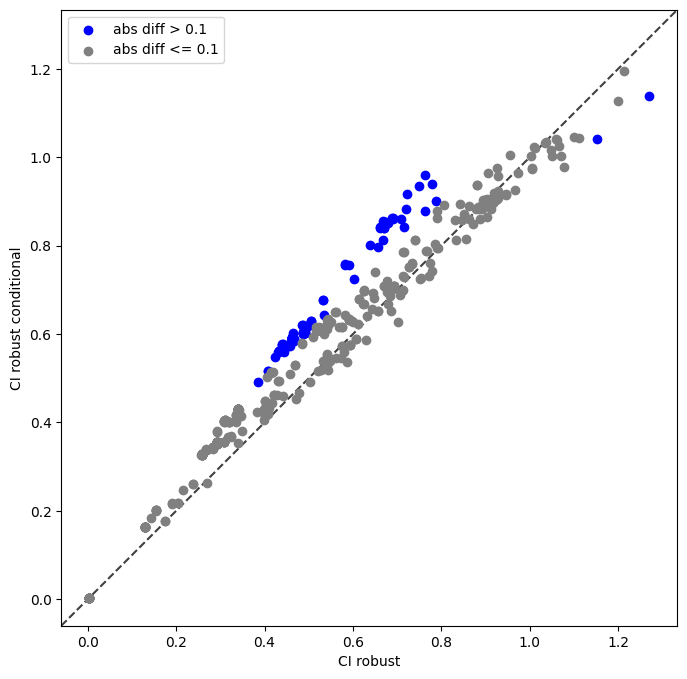

In [ ]:


import matplotlib.pyplot as plt
# Calculate the absolute difference
data['abs_diff'] = abs(data['CI_rob'] - data['CI_rob_cond_P'])

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the points with absolute difference > 0.1 in blue
ax.scatter(data[data['abs_diff'] > 0.1]['CI_rob'],
           data[data['abs_diff'] > 0.1]['CI_rob_cond_P'],
           color='blue', label='abs diff > 0.1')

# Plot the remaining points in gray
ax.scatter(data[data['abs_diff'] <= 0.1]['CI_rob'],
           data[data['abs_diff'] <= 0.1]['CI_rob_cond_P'],
           color='gray', label='abs diff <= 0.1')

# Add a 45-degree dotted line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),  # min of both axes
    max(ax.get_xlim()[1], ax.get_ylim()[1]),  # max of both axes
]
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(lims)
ax.set_ylim(lims)


# Set labels and title
ax.set_xlabel("CI robust")
ax.set_ylabel("CI robust conditional")
ax.set_title("") # No title

# Add legend
ax.legend()

# Show the plot
plt.show()

## Prepare data

### Subtask:
Select the relevant columns for the analysis.


**Reasoning**:
Select the relevant columns from the dataframe for the analysis.



In [ ]:
df_selected_2 = data[['Score_Ratio', 'Dimension', 'Age_Categ', 'Sector', 'Op_Inc_per_Worker', 'Result_per_Worker']]
display(df_selected_2.head())

,Score_Ratio,Dimension,Age_Categ,Sector,Op_Inc_per_Worker,Result_per_Worker
0,0.793729,1.Micro,Early-stage,AU,23.928407,0.198249
1,0.972475,4.Large,Established,MM,123.165238,16.088708
2,0.911447,3.Medium,Established,MM,90.063364,3.980946
3,0.910774,1.Micro,Established,TR,0.000000,-0.040148
4,0.768999,1.Micro,Established,ST,84.479687,4.813393


## Initial gam model

### Subtask:
Fit a GAM model using all specified contextual variables.


**Reasoning**:
Define the target and feature variables, encode the categorical features, define the GAM formula, and fit the LinearGAM model.



In [ ]:
from sklearn.preprocessing import LabelEncoder
from pygam import LinearGAM, s, f

# Define target variable
y_2 = df_selected_2['Score_Ratio']

# Define feature variables
X_2 = df_selected_2.drop('Score_Ratio', axis=1)

# Identify categorical columns
categorical_cols_2 = ['Dimension', 'Age_Categ', 'Sector']

# Apply Label Encoding to the categorical columns
le_dimension_2 = LabelEncoder()
le_age_2 = LabelEncoder()
le_sector_2 = LabelEncoder()

X_2['Dimension_Encoded'] = le_dimension_2.fit_transform(X_2['Dimension'])
X_2['Age_Categ_Encoded'] = le_age_2.fit_transform(X_2['Age_Categ'])
X_2['Sector_Encoded'] = le_sector_2.fit_transform(X_2['Sector'])

# Create a new DataFrame with encoded categorical columns and original continuous columns
X_2_encoded = X_2.drop(categorical_cols_2, axis=1)

# Define the list of encoded feature names
gam_features_2 = ['Op_Inc_per_Worker', 'Result_per_Worker', 'Dimension_Encoded', 'Age_Categ_Encoded', 'Sector_Encoded']
X_gam_2 = X_2_encoded[gam_features_2]

# Create GAM formula using the indices of the encoded features
# Based on the order in gam_features_2:
# Op_Inc_per_Worker (0): s() - continuous
# Result_per_Worker (1): s() - continuous
# Dimension_Encoded (2): f() - categorical
# Age_Categ_Encoded (3): f() - categorical
# Sector_Encoded (4): f() - categorical
gam_formula_2 = s(0) + s(1) + f(2) + f(3) + f(4)

# Instantiate and fit LinearGAM model with the encoded data
gam_2 = LinearGAM(gam_formula_2)
gam_2.fit(X_gam_2, y_2)

print("GAM model fitting complete with encoded categorical variables for Score_Ratio2.")

GAM model fitting complete with encoded categorical variables for Score_Ratio2.


## Summarize model

### Subtask:
Display the model summary, including p-values for each variable.


**Reasoning**:
Display the summary of the fitted GAM model to get the p-values for each variable.



In [ ]:
print(gam_2.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     31.2852
Link Function:                     IdentityLink Log Likelihood:                                -22287.0861
Number of Samples:                          490 AIC:                                            44638.7427
                                                AICc:                                           44643.4486
                                                GCV:                                                0.0107
                                                Scale:                                              0.0095
                                                Pseudo R-Squared:                                   0.1496
Feature Function                  Lam

/tmp/ipython-input-756424703.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_2.summary())


**Reasoning**:
Generate partial dependence plots for each term in the model to visualize their impact on the target variable and visually assess consistency with the p-values from the summary.



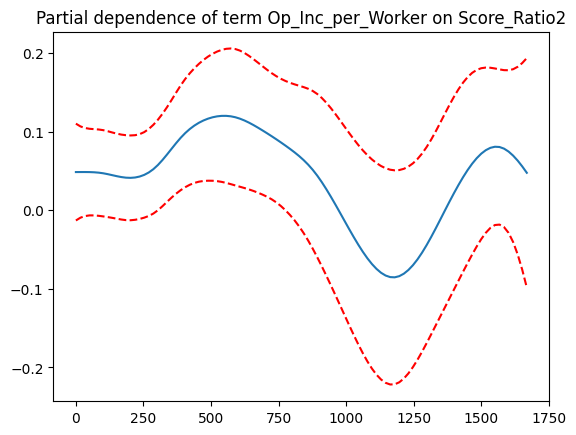

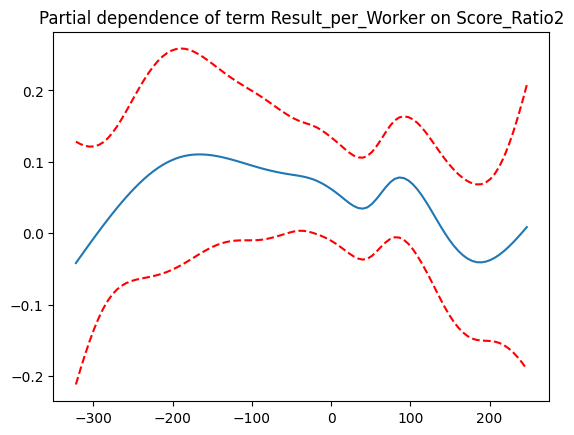

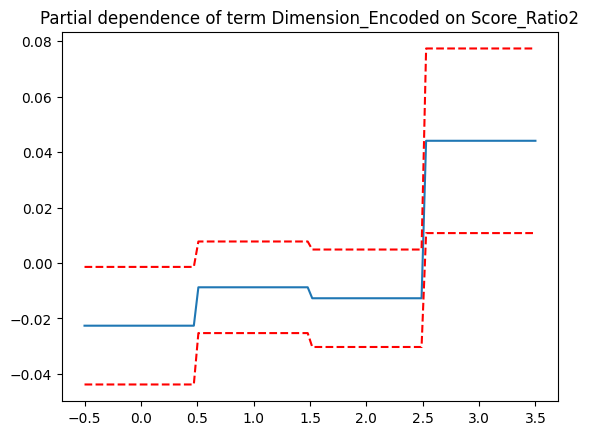

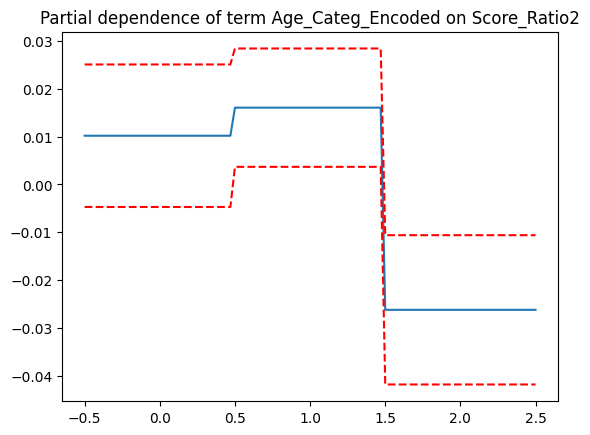

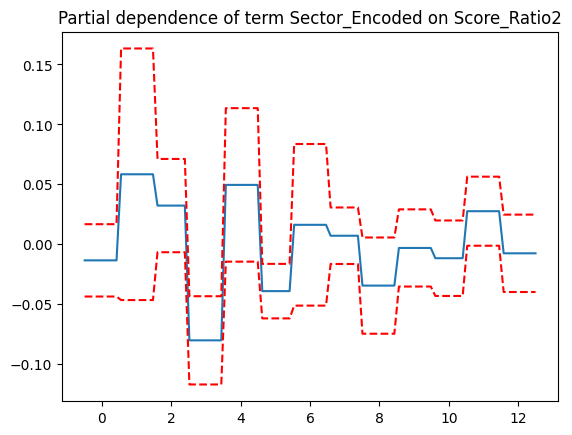

In [ ]:
import matplotlib.pyplot as plt

for i, term in enumerate(gam_2.terms):
    if term.isintercept:
        continue

    XX = gam_2.generate_X_grid(term=i)
    pdep, confi = gam_2.partial_dependence(term=i, X=XX, width=0.95)

    plt.figure()
    plt.plot(XX[:, i], pdep)
    plt.plot(XX[:, i], confi, c='r', ls='--')
    plt.title(f'Partial dependence of term {gam_features_2[i]} on Score_Ratio2')
    plt.show()

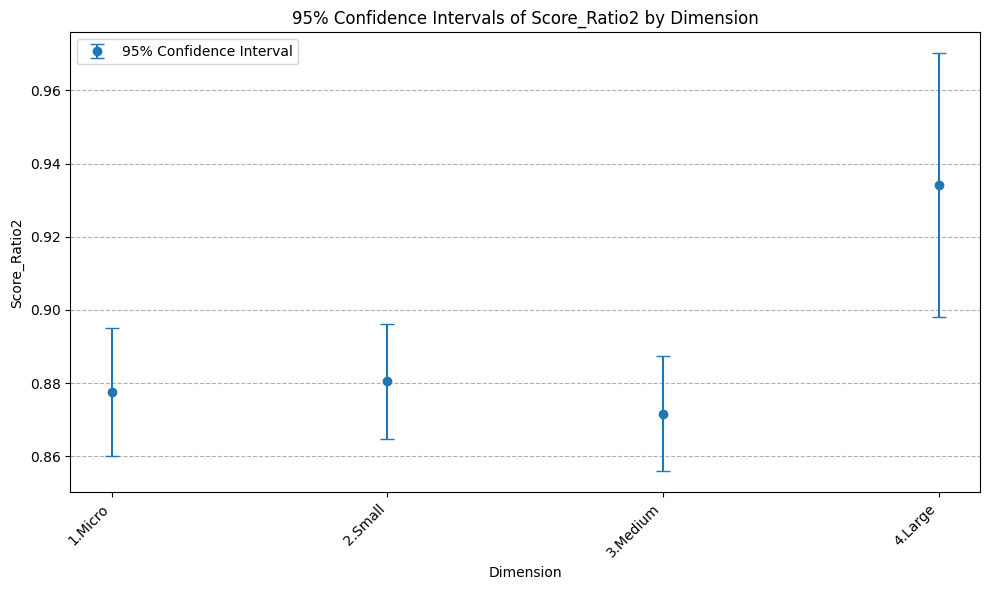

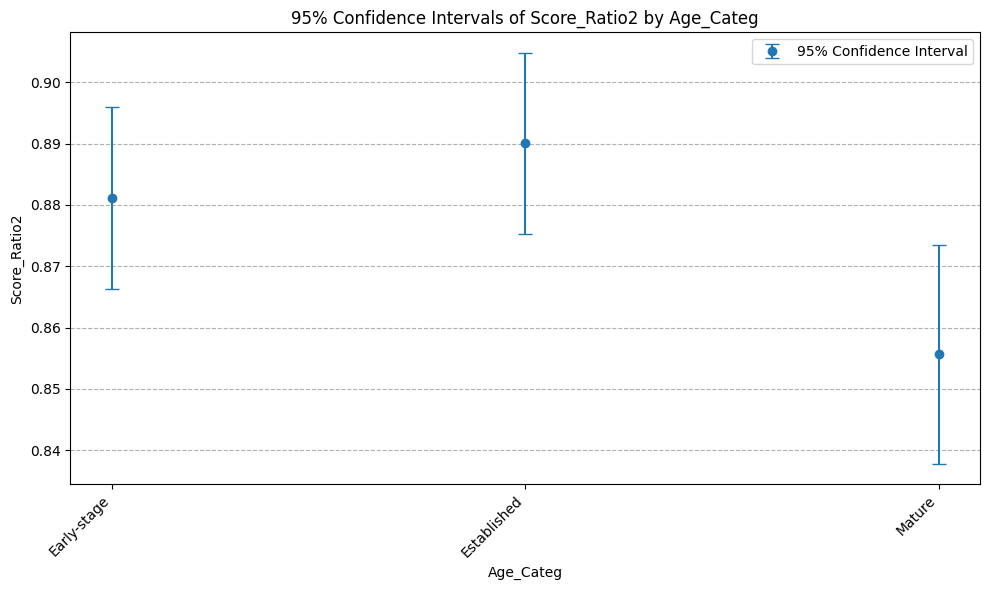

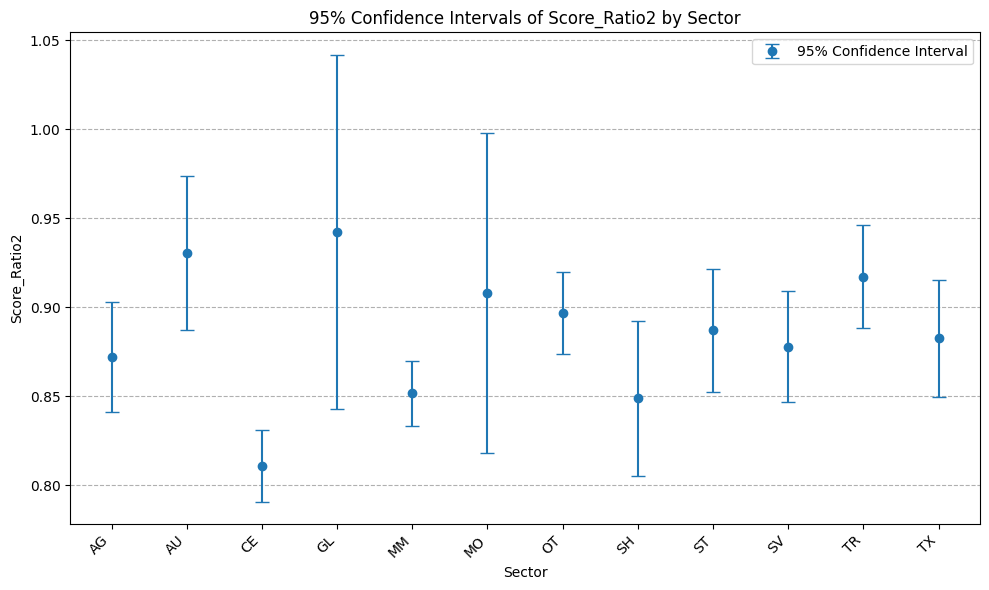

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
from google.colab import files
import os

# Function to calculate the confidence interval for each category
def calculate_categorical_ci(data, categorical_col, target_col, confidence_level=0.95):
    """
    Calculates the confidence interval for the mean of a target variable
    for each category in a specified categorical column.

    Args:
        data (pd.DataFrame): The input DataFrame.
        categorical_col (str): The name of the categorical column.
        target_col (str): The name of the target column (numerical).
        confidence_level (float): The desired confidence level (e.g., 0.95).

    Returns:
        pd.DataFrame: A DataFrame with columns 'Category', 'Mean', 'Lower_CI', 'Upper_CI'.
                      Categories are sorted alphabetically.
    """
    # Ensure the target column is numeric
    data = data.copy()
    data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
    data.dropna(subset=[target_col], inplace=True) # Drop rows where target is not numeric

    results = []
    for category in sorted(data[categorical_col].unique()): # Sort categories alphabetically
        subset = data[data[categorical_col] == category][target_col]
        if not subset.empty:
            mean = subset.mean()
            std_err = subset.sem() # Standard error of the mean
            # Use t-distribution for confidence interval
            from scipy.stats import t
            n = len(subset)
            if n > 1 and std_err > 0: # Check if there's enough data and variance
                h = std_err * t.ppf((1 + confidence_level) / 2., n - 1)
                lower_ci = mean - h
                upper_ci = mean + h
                results.append({'Category': category, 'Mean': mean, 'Lower_CI': lower_ci, 'Upper_CI': upper_ci})
            elif n == 1: # Case with only one data point
                 results.append({'Category': category, 'Mean': mean, 'Lower_CI': mean, 'Upper_CI': mean})
            else: # Case with no data points (after dropping NaNs) or no variance
                 results.append({'Category': category, 'Mean': float('nan'), 'Lower_CI': float('nan'), 'Upper_CI': float('nan')})


    return pd.DataFrame(results)

# Check if 'data' DataFrame exists. If not, attempt to reload from the previously uploaded file.
if 'data' not in globals():
    print("Loading data from previously uploaded file...")
    # Assuming the file name is still available or can be retrieved.
    # This is a simplification; in a real scenario, you might need to
    # prompt the user to re-upload or specify the file path.
    # For this example, let's assume a common name or try to list files.
    try:
        # Attempt to find the file name from the previous upload output or list files
        # This part is highly dependent on the execution environment and previous steps.
        # A more robust solution would involve re-uploading or having a fixed file path.
        # For demonstration, let's assume the file is named 'CI_Results.xlsx' or similar.
        file_name = 'CI_Results.xlsx' # Replace with the actual expected file name if known
        if os.path.exists(file_name):
             data = pd.read_excel(file_name, sheet_name='Summary', engine='openpyxl')
             print("Data reloaded successfully.")
        else:
            print(f"Error: Data file '{file_name}' not found. Please re-upload the data.")
            # As a fallback, you might prompt for upload again:
            # uploaded = files.upload()
            # file_name = list(uploaded.keys())[0]
            # data = pd.read_excel(file_name, sheet_name='Summary', engine='openpyxl')
            # print("Data uploaded and reloaded successfully.")

    except Exception as e:
        print(f"Error reloading data: {e}")
        data = None # Ensure data is None if loading fails

# Proceed only if data is loaded
if data is not None:
    # List of categorical columns for which to generate interval plots for Score_Ratio2
    categorical_cols_score_ratio2 = ['Dimension', 'Age_Categ', 'Sector']

    # We will use the 'df_selected_2' DataFrame which contains 'Score_Ratio2' and the original categorical variables
    # (before encoding in the GAM analysis for Task 2).
    # Ensure 'Score_Ratio' is used as the target column name
    df_for_interval_plots = data[['Score_Ratio', 'Dimension', 'Age_Categ', 'Sector']]

    # Generate interval plots for each categorical variable vs. Score_Ratio2
    for col in categorical_cols_score_ratio2:
        # Calculate confidence intervals for each category
        # Use 'Score_Ratio' as the target_col instead of 'Score_Ratio2'
        ci_df = calculate_categorical_ci(df_for_interval_plots, col, 'Score_Ratio')

        if not ci_df.empty:
            # Create the interval plot
            plt.figure(figsize=(10, 6))
            # Plot the confidence intervals as vertical lines
            if col == 'Sector':
                # Filter out 'AR' for the Sector plot
                ci_df_filtered = ci_df[ci_df['Category'] != 'AR'].copy()
                plt.errorbar(ci_df_filtered['Category'], ci_df_filtered['Mean'],
                             yerr=[ci_df_filtered['Mean'] - ci_df_filtered['Lower_CI'], ci_df_filtered['Upper_CI'] - ci_df_filtered['Mean']],
                             fmt='o', capsize=5, label='95% Confidence Interval') # fmt='o' removes lines
            else:
                plt.errorbar(ci_df['Category'], ci_df['Mean'],
                             yerr=[ci_df['Mean'] - ci_df['Lower_CI'], ci_df['Upper_CI'] - ci_df['Mean']],
                             fmt='o', capsize=5, label='95% Confidence Interval') # fmt='o' removes lines


            plt.title(f'95% Confidence Intervals of Score_Ratio2 by {col}')
            plt.xlabel(col)
            plt.ylabel('Score_Ratio2')
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
            plt.grid(axis='y', linestyle='--')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print(f"No data to plot for {col}")
else:
    print("Data DataFrame is not available. Cannot proceed with plotting.")